In [1]:
%matplotlib inline

import numpy
from matplotlib import pyplot

pyplot.rc('text', usetex=True)
pyplot.rc('figure', figsize=[12, 8], dpi=144)

# Linearly increasing opacity
# TODO: Get datasets for opacity based on hydride ion concentrations
def opacity(position, k=1.):
    return k + numpy.linalg.norm(position)

# If opaque photon gets absorbed
def scatter_probability(position):
    return 1/opacity(position)

# Linearly decreasing density from center of the star
# TODO: Get datasets for more realistic model
def density(position, rho=100.):
    return rho * (1 - numpy.linalg.norm(position))

# If dense, photon cannot travel very long
# TODO: Model based on frequency of photon (refractive index depends on density and frequency)
def optical_depth(position):
    return min(1/density(position), 1.)

# Generate a random scatter angle and displace photon along this angle by magnitude given by optical_depth
def scatter(position, optical_depth):
    # TODO: Can we use 1D random walk instead?
    cos_azimuth = numpy.random.uniform(-1., 1.)
    sin_azimuth = numpy.random.choice([-1, 1]) * numpy.sqrt(1 - cos_azimuth ** 2) # [0, 2 * pi]
    cos_polar = numpy.random.uniform(-1., 1.)
    sin_polar = numpy.sqrt(1 - cos_polar ** 2) # [0, pi]

    xy_projection = optical_depth * sin_polar

    return position + numpy.array([
        xy_projection * cos_azimuth,
        xy_projection * sin_azimuth,
        optical_depth * cos_polar
    ])

In [2]:
# TODO: Parallelise on GPU using PyTorch
def simulate(position):
    path = [position]
    time = 0
    while True:
        time += 1
        if numpy.random.random() < scatter_probability(position):
            position = scatter(position, optical_depth(position))
            path.append(position)
            if numpy.linalg.norm(position) >= 1.:
                return 'escaped', time, path
        else:
            return 'absorbed', time, path

In [3]:
from collections import defaultdict

distributions = defaultdict(list)

# Generate points in a sphere of radius 1
# TODO: Generate points such that number of photons at a starting position
# proportional to energy density (T^4) using a model for temperature at different
# distance from center of the star
# TODO: Add frequency parameter modelled using real data
x = numpy.random.uniform(-1., 1., 1000)
y = numpy.sqrt(1 - x ** 2) * numpy.random.uniform(-1., 1., 1000)
z = numpy.sqrt(1 - x ** 2 - y ** 2) * numpy.random.uniform(-1., 1., 1000)
starting_positions = numpy.vstack((x, y, z)).T

max_iterations = 1000

for position in starting_positions:
    event, time, path = simulate(position)
    distributions[event].append(time)

(array([788.,  63.,  20.,   2.,   1.,   0.,   0.,   0.,   0.,   1.]),
 array([ 1. ,  4.5,  8. , 11.5, 15. , 18.5, 22. , 25.5, 29. , 32.5, 36. ]),
 <BarContainer object of 10 artists>)

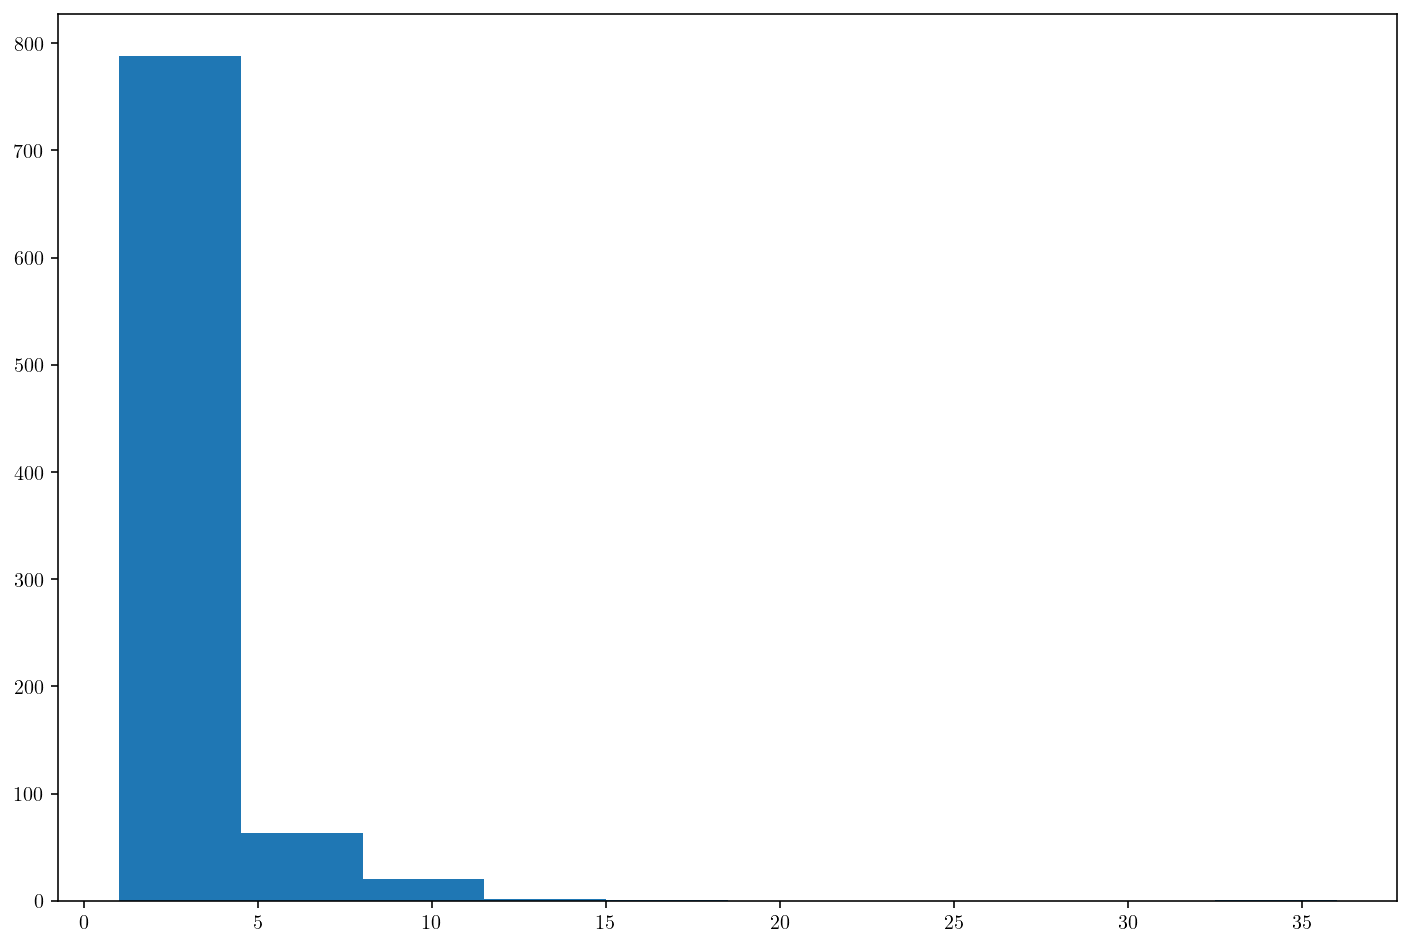

In [4]:
pyplot.hist(distributions['absorbed'], 10)

(array([106.,   0.,  13.,   0.,   0.,   3.,   0.,   1.,   0.,   2.]),
 array([1. , 1.4, 1.8, 2.2, 2.6, 3. , 3.4, 3.8, 4.2, 4.6, 5. ]),
 <BarContainer object of 10 artists>)

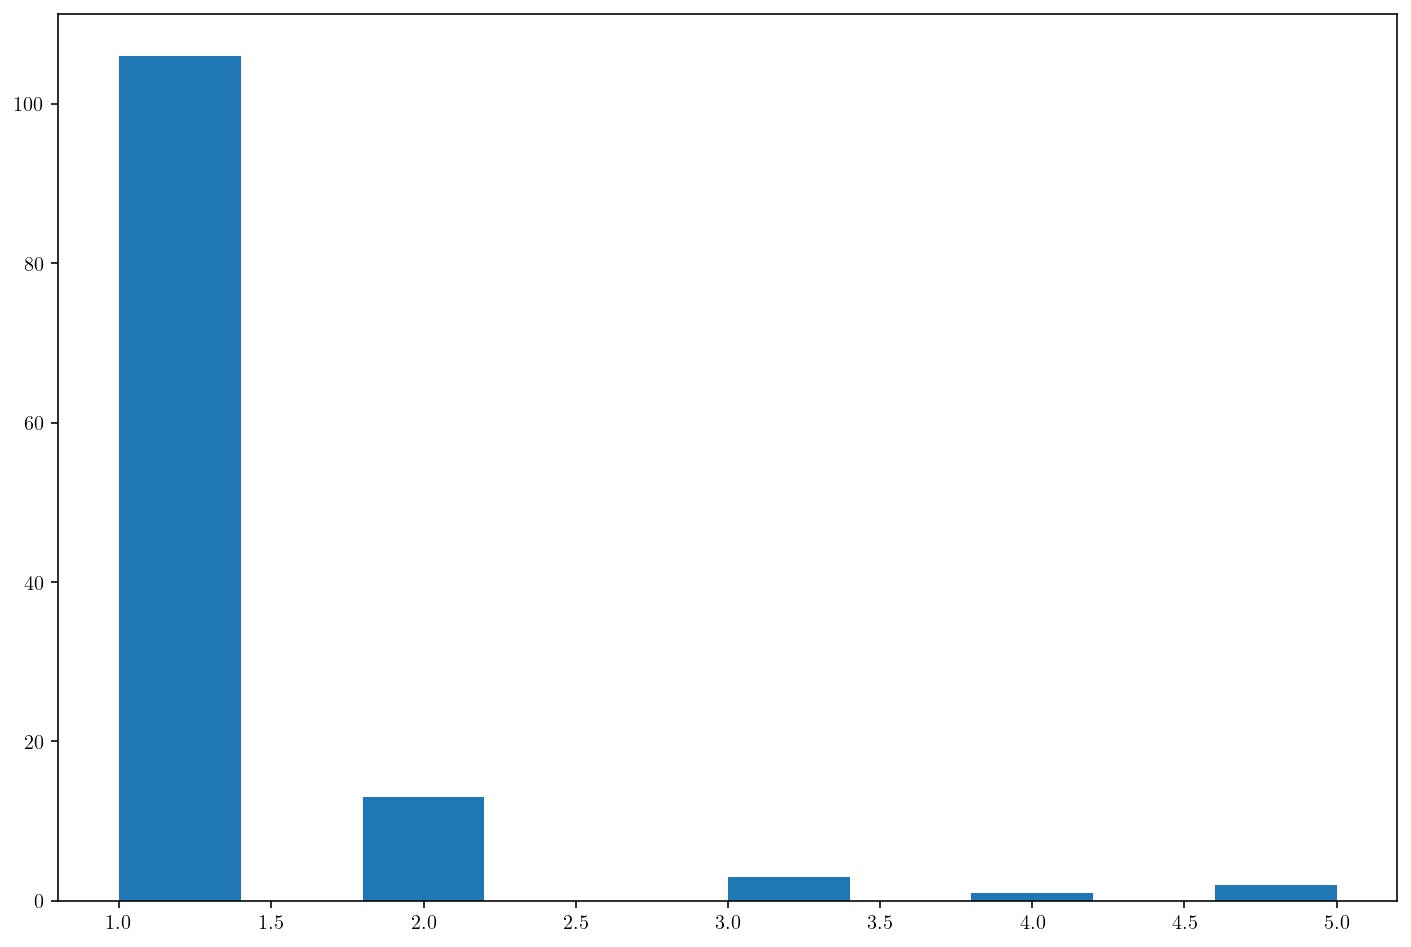

In [5]:
pyplot.hist(distributions['escaped'], 10)

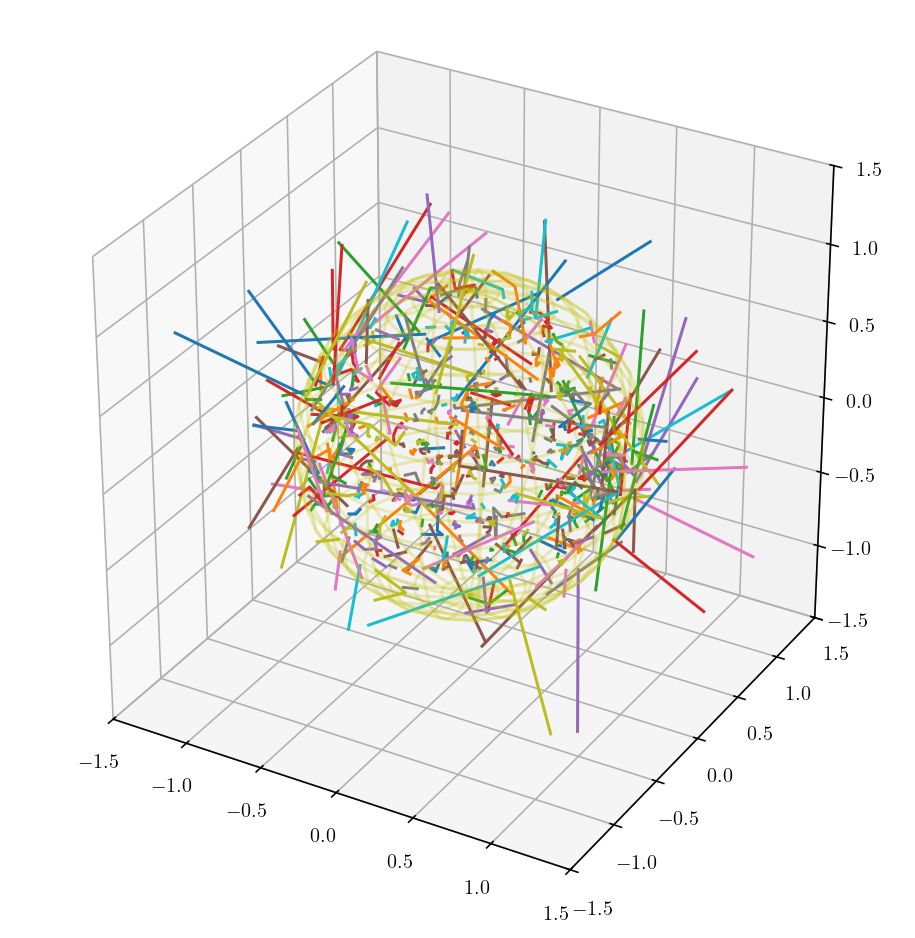

In [6]:
figure = pyplot.figure()
axes = figure.add_subplot(projection='3d')
axes.set_aspect('equal')
axes.set(xlim3d=(-1.5, 1.5))
axes.set(ylim3d=(-1.5, 1.5))
axes.set(zlim3d=(-1.5, 1.5))

phi, theta = numpy.mgrid[0:2*numpy.pi:20j, 0:numpy.pi:20j]
axes.plot_wireframe(numpy.cos(phi)*numpy.sin(theta), numpy.sin(phi)*numpy.sin(theta), numpy.cos(theta), color='y', alpha=0.25)

for i in range(1000):
    event, time, path = simulate(starting_positions[i])
    x, y, z = zip(*path)
    axes.plot3D(x, y, z)
pyplot.show()